<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Tarea 3, Comparación de Arquitecturas de Forecasting**

**Límite de entrega para ser evaluado sobre 100 puntos:** 20 de Agosto, 23:59 (UTC-3)

**Parte 1) Preparación de datos, 20 puntos**

* Fija las semillas para asegurar reproducibilidad.
* Utiliza el dataset Bike Sharing (Capital Bikeshare), que contiene fuerte estacionalidad horaria y semanal.
* Combina las columnas dteday/hr en una única marca temporal y convierte la serie al formato "long" (unique_id, ds, y) requerido por la librería.
* Maneja los valores faltantes de la variable objetivo (el sistema no siempre registró todas las horas: identifica los huecos reindexando a una grilla horaria completa y justifica el método elegido para completarlos).
* Define el horizonte de pronóstico: 24 horas (1 día).
* Define y justifica la longitud de la ventana de entrada (contexto) en función de la dinámica diaria/semanal de la serie (contraste día hábil vs. fin de semana).
* Define y justifica el tamaño del conjunto de test.

**Parte 2) Modelos, 40 puntos**

* Implementa y entrena N-BEATS (pérdida MAE).
* Implementa y entrena N-HiTS (pérdida MAE).
* Implementa y entrena DeepAR (pérdida basada en una distribución paramétrica DistributionLoss).
* Todos los modelos deben compartir el mismo horizonte, la misma ventana de entrada y la misma cantidad de pasos de entrenamiento, para que la comparación sea justa.
* Documenta brevemente las diferencias arquitectónicas entre los tres modelos.

**Parte 3) Evaluación y métricas, 20 puntos**

* Evalúa los tres modelos sobre el mismo conjunto de test.
* Calcula, como mínimo, MAE, RMSE y MAPE para cada modelo.
* Presenta los resultados en una tabla comparativa.

**Parte 4) Visualización e interpretación, 10 puntos**

* Genera un gráfico que muestre el histórico reciente, los valores reales del test y las predicciones de los tres modelos sobre el mismo eje temporal, incluyendo la banda de incertidumbre de DeepAR.
* Redacta una breve lectura de los resultados: ¿qué modelo tuvo mejor desempeño puntual? ¿el modelo ganador sigue bien los picos de la mañana y la tarde (commuting), o los suaviza/subestima? ¿el valor real cae dentro del intervalo de confianza de DeepAR la mayor parte de las horas?

**Parte 5) Preguntas de análisis, 10 puntos**

* ¿Por qué N-HiTS (en general) suele ser más eficiente computacionalmente que N-BEATS pese a compartir una filosofía similar? ¿Qué mecanismo arquitectónico lo permite?

* Con una sola ventana de test de 24 horas, ¿qué tan sólida es la comparación entre los tres modelos? ¿Qué harías para robustecer la evaluación (por ejemplo, ventanas móviles)?

In [1]:
# Importamos los datos (dataset real: Bike Sharing, Capital Bikeshare)
# Información del dataset en https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset
url = "https://raw.githubusercontent.com/muditp19/UCI_Bike-sharing-dataset/master/hour.csv"

### **Parte 1) Preparación de datos**

Serie horaria de alquiler de bicicletas (Capital Bikeshare, 2011–2012). Se fijan las semillas, se construye la marca temporal a partir de `dteday`/`hr`, se lleva la serie al formato *long* que requiere `neuralforecast`, se completan los huecos de la grilla horaria y se definen horizonte, ventana de entrada y tamaño del test.

- _Clase 5 "N-BEATS vs N-HiTS" y "Ejercicio N-BEATS vs N-HiTS" — parámetros (horizonte, ventana de entrada, max_steps) definidos al inicio; formato 'long' requerido por neuralforecast: columnas ['unique_id', 'ds', 'y']_
- _Clase 5 "Ejercicio N-BEATS vs N-HiTS" — serie real llevada a grilla regular y faltantes completados con interpolate(); mismo patrón en Clase 5 "TCN" (co2.interpolate())_
- _Clase 4 "Exploración de Series Multivariadas" — construcción del índice temporal combinando las columnas de fecha y hora_
- _Clase 3 "LSTM, GRU y Benchmark contra el Naive" — semillas de NumPy y PyTorch_

Silenciamos los mensajes de entrenamiento de Lightning para que el output quede legible

In [2]:
import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("lightning_fabric").setLevel(logging.ERROR)

Importamos las librerías necesarias

In [3]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS, DeepAR
from neuralforecast.losses.pytorch import MAE, DistributionLoss

2026-08-17 12:35:04,301	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-08-17 12:35:04,570	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Fijamos las semillas para reproducibilidad

In [4]:
np.random.seed(42)
torch.manual_seed(42)

Descargamos el dataset y combinamos las columnas de fecha (`dteday`) y hora (`hr`) en una única marca temporal

In [5]:
bicis = pd.read_csv(url)

# Combinamos día y hora en una única marca temporal
bicis["ds"] = pd.to_datetime(bicis["dteday"]) + pd.to_timedelta(bicis["hr"], unit="h")

print(f"{len(bicis)} registros, de {bicis['ds'].min()} a {bicis['ds'].max()}")
print(f"Variable objetivo: cnt (alquileres por hora)")

17379 registros, de 2011-01-01 00:00:00 a 2012-12-31 23:00:00
Variable objetivo: cnt (alquileres por hora)


Llevamos la serie al formato *long* que requiere `neuralforecast`: columnas `unique_id`, `ds`, `y`. Es una única serie, así que `unique_id` es constante.

In [6]:
serie = pd.Series(bicis["cnt"].values, index=bicis["ds"]).sort_index()

# Grilla horaria completa entre el primer y el último registro
grilla = pd.date_range(serie.index.min(), serie.index.max(), freq="h")

# Reindexar expone los huecos: las horas que el sistema nunca registró
serie = serie.reindex(grilla)

print(f"Horas esperadas en la grilla: {len(grilla)}")
print(f"Horas efectivamente registradas: {int(serie.notna().sum())}")
print(f"Huecos: {int(serie.isna().sum())}")

Horas esperadas en la grilla: 17544
Horas efectivamente registradas: 17379
Huecos: 165


Inspeccionamos cómo se distribuyen los huecos: no es lo mismo una hora suelta que un corte de varios días

In [7]:
faltantes = serie.isna()

# Agrupamos los huecos consecutivos para medir el largo de cada corte
bloques = (faltantes != faltantes.shift()).cumsum()[faltantes]
largos = bloques.value_counts()

print("Cortes por duración:")
for largo, cantidad in largos.value_counts().sort_index().items():
    print(f"  {cantidad:>3} corte(s) de {largo} hora(s)")

print("\nLos tres cortes más largos:")
for b in largos.head(3).index:
    horas = bloques[bloques == b].index
    print(f"  {horas[0]} a {horas[-1]}  ({len(horas)} horas)")

Cortes por duración:
   64 corte(s) de 1 hora(s)
    6 corte(s) de 2 hora(s)
    1 corte(s) de 6 hora(s)
    1 corte(s) de 12 hora(s)
    1 corte(s) de 13 hora(s)
    1 corte(s) de 22 hora(s)
    1 corte(s) de 36 hora(s)

Los tres cortes más largos:
  2012-10-29 01:00:00 a 2012-10-30 12:00:00  (36 horas)
  2011-01-26 18:00:00 a 2011-01-27 15:00:00  (22 horas)
  2011-08-27 18:00:00 a 2011-08-28 06:00:00  (13 horas)


**Método de relleno: interpolación lineal.** El 88% de los huecos son cortes de una o dos horas, casi todos de madrugada, donde la demanda es mínima y estable: interpolar entre las dos horas vecinas reproduce bien un valor que de todos modos es bajo. El corte más largo (36 horas, 29–30 de octubre de 2012) corresponde al huracán Sandy, cuando el sistema no operó; ahí la interpolación produce una transición suave entre el nivel previo y el posterior. La alternativa de imputar con ceros sería afirmar que hubo cero demanda registrada como dato real, y la de eliminar las filas rompería la grilla horaria regular que los modelos necesitan.

In [8]:
serie = serie.interpolate()

# Formato long requerido por neuralforecast
df = pd.DataFrame({
    "unique_id": "bike",
    "ds": serie.index,
    "y": serie.values,
})

print(f"Faltantes tras la interpolación: {int(df['y'].isna().sum())}")
df.head()

Faltantes tras la interpolación: 0


,unique_id,ds,y
0,bike,2011-01-01 00:00:00,16.0
1,bike,2011-01-01 01:00:00,40.0
2,bike,2011-01-01 02:00:00,32.0
3,bike,2011-01-01 03:00:00,13.0
4,bike,2011-01-01 04:00:00,1.0


**Horizonte:** 24 horas (un día completo), fijado por la consigna.

**Ventana de entrada: 168 horas (7 días).** La serie tiene doble estacionalidad. El ciclo diario es marcado pero el perfil de esos picos depende del día de la semana: un sábado no tiene picos, tiene una curva ancha de mediodía. Con una ventana de 24 o 48 horas el modelo no puede saber si el día que debe pronosticar es hábil o fin de semana. Con 168 horas ve la semana completa y la posición del día a predecir dentro de ella, que es la información que discrimina entre los dos regímenes.

In [9]:
horizonte = 24        # 24 horas a predecir
ventana_entrada = 168 # 7 días de contexto: un ciclo semanal completo
max_steps = 300    # pasos de entrenamiento, idénticos en los tres modelos

**Tamaño del test: las últimas 24 horas**, es decir el horizonte completo. Reproduce el escenario real de uso (al cerrar el día, pronosticar el día siguiente entero) y mantiene la comparación directa: un solo `predict()` evaluado sobre el mismo tramo para los tres modelos. Su limitación es que se trata de un único día.

In [10]:
train = df.iloc[:-horizonte].reset_index(drop=True)
test = df.iloc[-horizonte:].reset_index(drop=True)

print(f"Train: {len(train)} horas, hasta {train['ds'].max()}")
print(f"Test:  {len(test)} horas, {test['ds'].min()} a {test['ds'].max()}")

Train: 17520 horas, hasta 2012-12-30 23:00:00
Test:  24 horas, 2012-12-31 00:00:00 a 2012-12-31 23:00:00


### **Parte 2) Modelos**

Tres arquitecturas entrenadas sobre el mismo train, con idéntico horizonte, ventana de entrada y cantidad de pasos de entrenamiento.

- _Clase 4 "Forecasting Jerárquico" — DeepAR con h, input_size, max_steps, learning_rate, scaler_type="robust", random_seed; columna DeepAR-median y cuantiles en el predict_
- _Clase 5 "N-BEATS vs N-HiTS" / "Ejercicio N-BEATS vs N-HiTS" — NBEATS y NHITS con h, input_size, max_steps, loss=MAE(), random_seed=42; hiperparámetros equivalentes para que la comparación sea justa; un único NeuralForecast(models=[...]) con fit y predict_

**Diferencias arquitectónicas.**

* **DeepAR** es de una familia distinta: una LSTM autorregresiva que en cada paso no emite un número sino los **parámetros de una distribución** (acá una Student-t). Se entrena maximizando la verosimilitud mediante `DistributionLoss` en lugar de minimizar un error puntual, y al predecir muestrea múltiples trayectorias, de las que se derivan la mediana y los cuantiles. Dos rasgos lo separan de los otros dos. Es el único **probabilístico**, y es el único que construye el horizonte de forma **recursiva**: hace un rollout autoregresivo, realimentando cada predicción como entrada de la siguiente, con el costo conocido de esa estrategia (acumulación de error y *exposure bias*). N-BEATS y N-HiTS son determinísticos y emiten las 24 horas en una sola pasada, sin realimentación. Además, DeepAR está pensado como modelo **global**: su fortaleza es compartir parámetros entre muchas series para generalizar incluso con series de poca historia, algo que en esta tarea, con una única serie, no tiene dónde expresarse.

<img src=DeepAR.png width="800">

* **N-BEATS** apila bloques de perceptrones multicapa conectados por una doble residual, a través de bloques y a través de stacks: cada bloque emite un *backcast* (su reconstrucción de la ventana de entrada) y un *forecast* (su aporte a la predicción). El backcast se resta de la entrada antes de pasar al bloque siguiente, de modo que cada bloque trabaja sobre lo que los anteriores no lograron explicar, y la predicción final es la suma de los forecast parciales. El mecanismo es análogo al de los modelos de *boosting* —cada bloque corrige el error del anterior— con la diferencia de que acá ocurre dentro de una única red entrenada de punta a punta. Es la descomposición temporal incorporada a la arquitectura como sesgo inductivo: un bloque puede especializarse en la tendencia y dejar como residuo las fluctuaciones estacionales para que las modele el siguiente. No usa recurrencia ni convoluciones: opera sobre la ventana entera de una sola vez.

<img src=n-beats.png width="600">

* **N-HiTS** conserva esa filosofía de bloques residuales y agrega dos mecanismos que atacan la principal dificultad de N-BEATS, su costo computacional y de memoria cuando el **horizonte es largo**: *multi-rate sampling* (cada stack submuestrea la entrada con un pooling, así que la ve a distinta resolución) e *interpolación jerárquica* (cada stack predice pocos puntos y los expande al horizonte interpolando). El efecto es doble: cada stack se especializa en una banda de frecuencias —los de pooling grande capturan el movimiento lento, los de pooling chico el detalle fino— y se reduce el número de parámetros efectivos que hacen falta para cubrir un horizonte dado.

<img src=h-hits.png width="800">

Construimos los tres modelos con hiperparámetros equivalentes para que la comparación sea justa

In [11]:
modelos = [
    NBEATS(
        h=horizonte,
        input_size=ventana_entrada,
        max_steps=max_steps,
        loss=MAE(),
        random_seed=42,
        enable_progress_bar=False,
    ),
    NHITS(
        h=horizonte,
        input_size=ventana_entrada,
        max_steps=max_steps,
        loss=MAE(),
        random_seed=42,
        enable_progress_bar=False,
    ),
    DeepAR(
        h=horizonte,
        input_size=ventana_entrada,
        max_steps=max_steps,
        # Pérdida paramétrica: la red estima los parámetros de una Student-t,
        # cuyas colas pesadas toleran mejor los picos de demanda que una Normal
        loss=DistributionLoss(distribution="StudentT", level=[80, 90]),
        scaler_type="robust",
        random_seed=42,
        enable_progress_bar=False,
    ),
]

Seed set to 42


Seed set to 42


Seed set to 42


Entrenamos los tres modelos sobre el mismo train y predecimos el horizonte siguiente

In [12]:
nf = NeuralForecast(models=modelos, freq="h")
nf.fit(df=train)
forecast = nf.predict()

print("\nColumnas devueltas por predict():")
print(list(forecast.columns))

GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


2026-08-17 12:35:19.226316: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name         ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss         │ MAE           │      0 │ train │     0 │
│ 1 │ padder_train │ ConstantPad1d │      0 │ train │     0 │
│ 2 │ scaler       │ TemporalNorm  │      0 │ train │     0 │
│ 3 │ blocks       │ ModuleList    │  2.8 M │ train │     0 │
└───┴──────────────┴───────────────┴────────┴───────┴───────┘

...

💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


GPU available: False, used: False


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Columnas devueltas por predict():
['unique_id', 'ds', 'NBEATS', 'NHITS', 'DeepAR', 'DeepAR-median', 'DeepAR-lo-90', 'DeepAR-lo-80', 'DeepAR-hi-80', 'DeepAR-hi-90']


Documentamos el tamaño de cada modelo

In [13]:
for modelo in nf.models:
    n_params = sum(p.numel() for p in modelo.parameters())
    print(f"{type(modelo).__name__:<10} {n_params:>10,} parámetros")

NBEATS      2,781,666 parámetros
NHITS       2,817,570 parámetros
DeepAR        199,560 parámetros


### **Parte 3) Evaluación y métricas**

- _Clase 5 "Ejercicio N-BEATS vs N-HiTS" — funciones mae, rmse y mape; evaluar_modelos(test, forecast, nombres_modelos) devolviendo la tabla con pd.DataFrame_

Definimos las métricas de evaluación

In [14]:
def mae(y_real, y_pred):
    return float(np.mean(np.abs(y_real - y_pred)))


def rmse(y_real, y_pred):
    return float(np.sqrt(np.mean((y_real - y_pred) ** 2)))


def mape(y_real, y_pred):
    return float(np.mean(np.abs((y_real - y_pred) / y_real)) * 100)

Definimos la función que evalúa cada modelo sobre el mismo conjunto de test

In [15]:
def evaluar_modelos(test, forecast, nombres_modelos):

    y_real = test["y"].values
    resultados = []

    for nombre in nombres_modelos:
        y_pred = forecast[nombre].values
        resultados.append({
            "modelo": nombre,
            "MAE": mae(y_real, y_pred),
            "RMSE": rmse(y_real, y_pred),
            "MAPE (%)": mape(y_real, y_pred),
        })

    return pd.DataFrame(resultados)

Verificamos el mínimo del test antes de calcular el MAPE: si alguna hora tuviera demanda cero, la división sería inválida.

In [16]:
print(f"Mínimo de y en el test: {test['y'].min():.0f}")
print(f"Horas del test con y < 10: {(test['y'] < 10).sum()}")

Mínimo de y en el test: 1
Horas del test con y < 10: 3


De DeepAR usamos la **mediana** como pronóstico puntual: es la columna que resume su distribución predictiva y, siendo el minimizador teórico del error absoluto, es la comparación justa contra dos modelos entrenados con pérdida MAE.

In [17]:
nombres_modelos = ["NBEATS", "NHITS", "DeepAR-median"]
tabla_resultados = evaluar_modelos(test, forecast, nombres_modelos)
tabla_resultados

,modelo,MAE,RMSE,MAPE (%)
0,NBEATS,38.847901,59.852557,64.720167
1,NHITS,44.122903,65.263713,66.402284
2,DeepAR-median,64.908413,86.407289,116.114394


### **Parte 4) Visualización e interpretación**

- _Clase 5 "Ejercicio N-BEATS vs N-HiTS" — graficar_comparacion(train, test, forecast, nombres_modelos, ultimos_n): histórico reciente, real del test y predicciones sobre el mismo eje temporal_
- _Clase 4 "Forecasting Jerárquico" — DeepAR-median y columnas de cuantiles devueltas por el predict_

Definimos la función de visualización, agregando la banda de incertidumbre de DeepAR

In [18]:
def graficar_comparacion(train, test, forecast, nombres_modelos, ultimos_n=72):

    historico = train.tail(ultimos_n)

    fig, ax = plt.subplots(figsize=(13, 5))

    # Histórico reciente y valores reales del test, ambos en negro: son el dato
    ax.plot(historico["ds"], historico["y"], color="black", linewidth=1.2,
            label="Histórico (train)")
    ax.plot(test["ds"], test["y"], color="black", linewidth=2, linestyle="--",
            marker="o", markersize=4, label="Real (test)")

    # Banda de incertidumbre del 90% de DeepAR
    ax.fill_between(forecast["ds"], forecast["DeepAR-lo-90"], forecast["DeepAR-hi-90"],
                    color="#1baf7a", alpha=0.15, label="DeepAR, intervalo 90%")

    # Una línea por modelo
    colores = {"NBEATS": "#2a78d6", "NHITS": "#eb6834", "DeepAR-median": "#1baf7a"}
    for nombre in nombres_modelos:
        ax.plot(forecast["ds"], forecast[nombre], color=colores[nombre],
                linewidth=1.8, marker="x", markersize=5, label=nombre)

    # Marcamos dónde termina el histórico y empieza el pronóstico
    ax.axvline(test["ds"].min(), color="#8C8C8C", linewidth=1, linestyle=":")

    ax.set_xlabel("Fecha y hora")
    ax.set_ylabel("Alquileres por hora")
    ax.set_title("Pronóstico a 24 horas: N-BEATS vs N-HiTS vs DeepAR")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

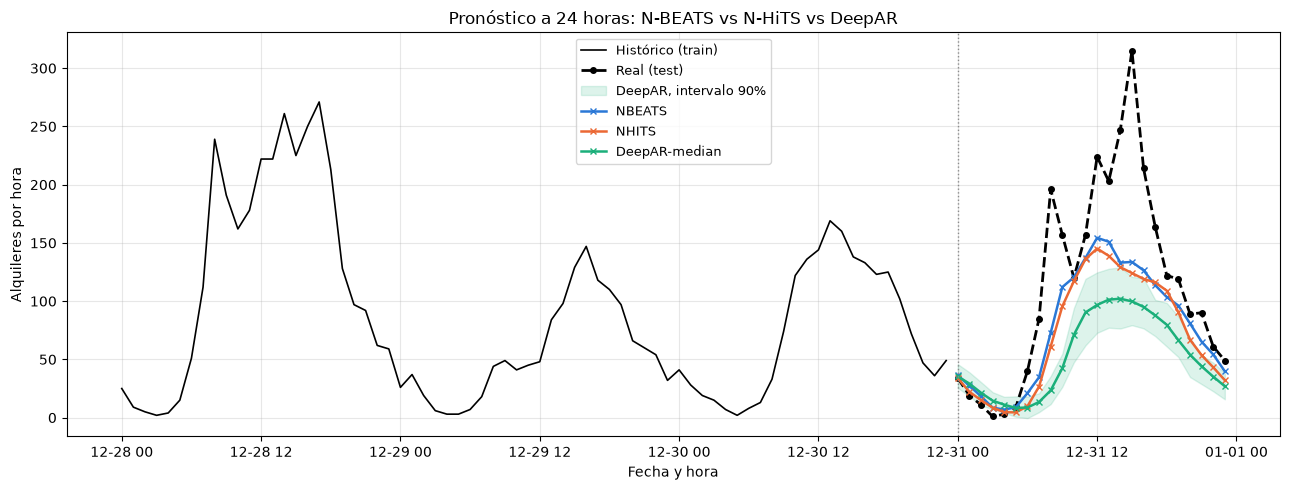

In [19]:
graficar_comparacion(train, test, forecast, nombres_modelos, ultimos_n=72)

Medimos qué proporción de las horas reales cae dentro del intervalo del 90% de DeepAR

In [20]:
y_real = test["y"].values
dentro = (y_real >= forecast["DeepAR-lo-90"].values) & (y_real <= forecast["DeepAR-hi-90"].values)

print(f"Cobertura empírica del intervalo 90%: {dentro.sum()}/{len(y_real)} horas "
      f"({dentro.mean() * 100:.0f}%)")

# Ancho medio del intervalo, para dimensionar el precio de esa cobertura
ancho = (forecast["DeepAR-hi-90"] - forecast["DeepAR-lo-90"]).mean()
print(f"Ancho medio del intervalo 90%: {ancho:.0f} alquileres")

Cobertura empírica del intervalo 90%: 4/24 horas (17%)
Ancho medio del intervalo 90%: 31 alquileres


Comparamos el comportamiento en las horas pico contra el resto del día. Las horas pico no se fijan a mano: se derivan del perfil horario medio de los días hábiles del train, tomando aquellas cuya demanda supera la media diaria en más de un desvío estándar.

In [21]:
# Perfil horario medio de los dias habiles del train, segun la marca workingday del dataset
habil = bicis.set_index("ds")["workingday"]
perfil = (train.assign(hora=train["ds"].dt.hour, habil=train["ds"].map(habil))
               .query("habil == 1")
               .groupby("hora")["y"].mean())

# Son pico las horas que superan la demanda media de un dia habil en mas de un desvio
umbral = perfil.mean() + perfil.std()
horas_pico = perfil[perfil > umbral].index.to_numpy()

print(f"Demanda media de un dia habil: {perfil.mean():.0f} alquileres/hora (desvio {perfil.std():.0f})")
print(f"Umbral de pico: {umbral:.0f}")
print(f"Horas pico derivadas del train: {list(horas_pico)}")

Demanda media de un dia habil: 192 alquileres/hora (desvio 154)
Umbral de pico: 346
Horas pico derivadas del train: [8, 17, 18, 19]


In [22]:
horas = test["ds"].dt.hour.values
pico = np.isin(horas, horas_pico)

print(f"{'modelo':<16}{'MAE pico':>10}{'MAE resto':>11}{'sesgo pico':>13}")
print("-" * 50)
for nombre in nombres_modelos:
    pred = forecast[nombre].values
    error_pico = np.mean(np.abs(pred[pico] - y_real[pico]))
    error_resto = np.mean(np.abs(pred[~pico] - y_real[~pico]))

    # Sesgo: negativo significa que el modelo subestima el pico
    sesgo = np.mean(pred[pico] - y_real[pico])
    print(f"{nombre:<16}{error_pico:>10.1f}{error_resto:>11.1f}{sesgo:>13.1f}")

modelo            MAE pico  MAE resto   sesgo pico
--------------------------------------------------
NBEATS                53.7       35.9        -53.7
NHITS                 56.1       41.7        -56.1
DeepAR-median         85.9       60.7        -85.9


El día de test está marcado como hábil en el dataset, pero conviene verificar si su forma sigue realmente el perfil de un día hábil, porque de eso depende cómo se lee el análisis de picos.

In [23]:
perfil_test = pd.Series(y_real, index=horas)

print(f"{'hora':>6}{'habil (train)':>16}{'dia de test':>14}")
for h in sorted(set(list(horas_pico) + [int(perfil.idxmax()), int(perfil_test.idxmax())])):
    print(f"{h:>5}h{perfil[h]:>16.0f}{perfil_test[h]:>14.0f}")

print(f"\nHora del maximo   -> dia habil tipico: {perfil.idxmax()}h | dia de test: {perfil_test.idxmax()}h")
print(f"Total del dia     -> dia habil tipico: {perfil.sum():.0f} | dia de test: {y_real.sum():.0f}")

  hora   habil (train)   dia de test
    8h             478           196
   15h             201           315
   17h             526           164
   18h             493           122
   19h             349           119

Hora del maximo   -> dia habil tipico: 17h | dia de test: 15h
Total del dia     -> dia habil tipico: 4613 | dia de test: 2729


**Lectura de los resultados.**

**¿Qué modelo tuvo mejor desempeño puntual?** N-BEATS, en las tres métricas a la vez: MAE 38.8 contra 44.1 de N-HiTS y 64.9 de DeepAR, con el mismo orden en RMSE (59.9 / 65.3 / 86.4) y en MAPE (64.7% / 66.4% / 116.1%). Que N-HiTS quede por detrás de N-BEATS reproduce lo que ocurrió en el ejercicio de clase sobre la serie de CO2, donde N-HiTS también registró un error más alto: la ventaja de N-HiTS no está en la precisión puntual sino en la eficiencia con horizontes largos, y con 24 pasos no llega a expresarse (se retoma en la Parte 5).

Que DeepAR quede último tiene tres explicaciones que se suman, y ninguna es que sea una arquitectura inferior:

1. **Es el único recursivo.** Construye las 24 horas realimentando cada predicción como entrada de la siguiente, así que el error de las primeras horas se propaga al resto. N-BEATS y N-HiTS emiten el horizonte completo de una pasada y no acumulan.
2. **Es un modelo global usado en una sola serie.** Su diseño apunta a compartir parámetros entre muchas series; acá entrena sobre una, de modo que no puede aprovechar aquello que lo hace fuerte.
3. **Optimiza otra cosa.** Entrenado por verosimilitud sobre una Student-t, busca describir toda la distribución, mientras que los otros dos minimizan directamente el error absoluto que la tabla mide.

Sobre el MAPE conviene una advertencia: supera el 60% en todos los modelos no porque el pronóstico sea malo en esa magnitud, sino porque tres horas de la madrugada tienen demanda de entre 1 y 9 bicicletas. Un error de 20 unidades sobre un valor real de 1 aporta 2000 puntos porcentuales a un promedio de 24 términos. Con denominadores tan chicos el MAPE deja de ser informativo y el MAE es la métrica que hay que mirar.

**¿El ganador sigue los picos de la mañana y la tarde, o los subestima?** Los subestima, y de forma sistemática. Las horas pico no se eligieron a mano: salen del perfil horario de los días hábiles del train, tomando las que superan la demanda media diaria en más de un desvío, y resultan ser las 8, 17, 18 y 19. En ellas el MAE de N-BEATS sube a 53.7 frente a 35.9 en el resto del día, y su sesgo es de −53.7, idéntico en magnitud al MAE: eso significa que **en cada una de esas horas la predicción quedó por debajo del valor real**, sin una sola sobreestimación que compensara. El mismo patrón aparece en N-HiTS (−56.1) y en DeepAR (−85.9).

El gráfico muestra por qué. El 31 de diciembre real trepa por encima de los 300 alquileres cerca del mediodía, mientras que N-BEATS y N-HiTS techan alrededor de 150 y DeepAR ni siquiera llega a 110: los tres producen una curva suave de la forma correcta pero de aproximadamente la mitad de amplitud. Los tres días previos que forman el contexto (28, 29 y 30 de diciembre) tienen máximos de entre 150 y 270, así que los modelos extrapolaron un día parecido a esa semana y el 31 resultó bastante más activo que cualquiera de ellos.

Conviene señalar una limitación del análisis de picos. El dataset marca el 31 de diciembre como día hábil (`workingday = 1`), pero su forma no se parece a la de un día hábil típico: movió su máximo de las 17 a las 15 horas y acumuló 2.729 alquileres frente a los 4.613 de un hábil promedio. En las horas pico la brecha es drástica (a las 17 horas el perfil habitual marca 526 alquileres y ese día hubo 164) de modo que el análisis mide el error en horas que, para esta fecha en particular, no fueron picos.

**¿El valor real cae dentro del intervalo de DeepAR la mayor parte de las horas?** No: solo en 4 de 24 horas, un 17% de cobertura empírica frente al 90% nominal. El intervalo está mal calibrado por dos motivos que se suman. Es demasiado angosto (31 alquileres de ancho medio, cuando la serie recorre ese día un rango de más de 300) y además está centrado en una mediana que ya viene sesgada hacia abajo. Una banda estrecha alrededor de un centro equivocado falla en casi todas las horas. En la práctica esto significa que la incertidumbre que reporta DeepAR no es utilizable como está: el modelo se declara mucho más seguro de lo que sus errores justifican.

### **Parte 5) Preguntas de análisis**

**1) ¿Por qué N-HiTS suele ser más eficiente computacionalmente que N-BEATS pese a compartir una filosofía similar? ¿Qué mecanismo arquitectónico lo permite?**

El mecanismo es doble y actúa en los dos extremos de cada bloque:

* **Multi-rate sampling a la entrada.** Antes de procesar la ventana, cada stack de N-HiTS le aplica un *max pooling* con un tamaño de kernel distinto. Un stack con pooling de tamaño 8 recibe una versión submuestreada de la ventana, ocho veces más corta, de modo que la primera capa de su MLP tiene ocho veces menos entradas. Como en estas arquitecturas casi todo el costo está en capas totalmente conectadas, acortar la entrada reduce proporcionalmente los parámetros y las operaciones de ese stack. N-BEATS, en cambio, alimenta cada bloque con la ventana completa a resolución plena.

* **Interpolación jerárquica a la salida.** N-BEATS emite los `h` valores del horizonte directamente desde una capa lineal, cuyo tamaño crece con `h`. Cada stack de N-HiTS emite en cambio unos pocos puntos de control y los expande al horizonte por interpolación temporal. La capa de salida deja de escalar con el horizonte y pasa a escalar con la cantidad, mucho menor, de puntos de control.

El efecto combinado es que el costo de N-HiTS crece mucho más despacio que el de N-BEATS a medida que se alargan la ventana y el horizonte, y que cada stack queda especializado en una banda de frecuencias distinta.

En esta corrida esa ventaja no se materializó: con los hiperparámetros por defecto de `neuralforecast`, N-HiTS terminó con 2.817.570 parámetros contra 2.781.666 de N-BEATS, un 1% más, y además perdió en MAE. No es una contradicción, porque la eficiencia de N-HiTS es una propiedad de escala: el problema que vino a resolver es el costo computacional y de memoria de N-BEATS en horizontes largos (del orden de semanas o meses en aplicaciones industriales) y es ahí donde la capa de salida de N-BEATS se vuelve cara. Con `h = 24` esa capa es pequeña en ambos modelos, la configuración por defecto de la librería iguala anchos de MLP y cantidad de bloques, y la ventaja no alcanza a expresarse. El mismo fenómeno se vio en el ejercicio de clase sobre la serie de CO2, donde N-HiTS también quedó por detrás de N-BEATS en las tres métricas.

**2) Con una sola ventana de test de 24 horas, ¿qué tan sólida es la comparación entre los tres modelos? ¿Qué harías para robustecer la evaluación?**

Es poco sólida, y este caso lo ilustra bien. La comparación descansa en 24 puntos de un único día, y ese día es el 31 de diciembre: el dataset lo marca como día hábil, pero se comporta como una víspera de feriado, con el máximo desplazado a las 15 horas y un volumen total un 40% menor que el de un día hábil promedio. Peor aún, su ventana de contexto son los siete días previos, es decir la semana de Navidad, también atípica. Los modelos fueron evaluados prediciendo un día raro a partir de una semana rara. Nada garantiza que el orden N-BEATS > N-HiTS > DeepAR se mantenga en un martes de mayo, y la diferencia de 5.3 puntos de MAE entre los dos primeros es lo bastante chica como para invertirse con facilidad.

Qué calcularía para robustecerla, en orden de importancia:

1. **Validación con ventanas móviles.** `nf.cross_validation(df=df, n_windows=K, step_size=24)` con K del orden de 30 a 60 evalúa cada modelo sobre K días distintos, cubriendo días hábiles y fines de semana, invierno y verano. En lugar de un número por modelo se obtiene una distribución: reportaría media y desvío del MAE por modelo, y la proporción de ventanas en que cada uno gana. Una diferencia es sostenible si el intervalo media ± 2·desvío/√K de la diferencia pareada no contiene al cero.
2. **Repetición con varias semillas.** Reentrenar cambiando solo `random_seed` separa el efecto de la arquitectura del azar de la inicialización. Es una precaución para considerar la sensibilidad de estos modelos a la semilla aleatoria, y sin ella no se puede atribuir a N-BEATS una superioridad sobre N-HiTS que podría ser ruido de entrenamiento.
3. **Desagregación del error por hora del día y por tipo de día.** El análisis de picos ya mostró que el error se concentra en las horas de mayor demanda; separar días hábiles de fines de semana y feriados diría si algún modelo es sistemáticamente mejor en un régimen y peor en otro, algo que el promedio global esconde. En el caso de DeepAR habría que medir además el error por paso del horizonte: si crece con la distancia, confirmaría la acumulación de error propia de la estrategia recursiva.
4. **Para DeepAR, evaluar la calibración, no solo el punto.** Con K ventanas se puede medir la cobertura empírica del intervalo del 90% sobre cientos de horas y compararla con el 90% nominal, en lugar de estimarla con 24 observaciones. El 17% obtenido acá sugiere un problema real de calibración, pero con una sola ventana no se distingue un modelo mal calibrado de un día excepcional.

Es la misma conclusión a la que llegamos en la Tarea 2 con el embedding: una diferencia observada una sola vez, sin repetición ni medida de dispersión, no se distingue del ruido.